In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
hbar = 6.582e-22
def read_file(data_file):
    data = np.loadtxt(data_file, delimiter=',')
    time = data[:,0] * hbar
    rho = data[:,2:2+4*206]
    P0 = rho[:,::4]
    Pz = rho[:,3::4]

    f_e = 0.5*P0*(1+Pz)
    f_m = 0.5*P0*(1-Pz)

    return time, f_e, f_m, rho

def read_eps_file(eps_file):
    data = np.loadtxt(eps_file, delimiter=',')
    return data[0], data[1]

def s_classical(fe, fm, eps, w):
    se = np.zeros(len(eps))
    for i in range(len(se)):
        if fe[i] > 0 and fe[i] < 1:
            se[i] += fe[i] * np.log(fe[i]) + (1-fe[i]) * np.log(1-fe[i])
        if fm[i] > 0 and fm[i] < 1:
            se[i] += fm[i] * np.log(fm[i]) + (1-fm[i]) * np.log(1-fm[i])
    se *= -eps**2 / (2 * np.pi**2)

    return np.sum(se * w)

def s_quantum(r, eps, w):
    se = np.zeros(len(eps))
    for i in range(len(se)):
        den = r[4*i:4*i+4]
        lam1 = 0.5 * den[0] + 0.5 * den[0] * np.sqrt(np.sum(den[1:]**2))
        lam2 = 0.5 * den[0] - 0.5 * den[0] * np.sqrt(np.sum(den[1:]**2))

        if lam1 > 0 and lam1 < 1:
            se[i] += lam1 * np.log(lam1) + (1-lam1) * np.log(1-lam1)
        if lam2 > 0 and lam2 < 1:
            se[i] += lam2 * np.log(lam2) + (1-lam2) * np.log(1-lam2)

    se *= -eps**2 / (2 * np.pi**2)
    return np.sum(se * w)

def entropy(fe, fm, rho, eps, w):
    s = np.zeros(len(fe[:,0]))
    sq = np.zeros_like(s)

    for i in range(len(s)):
        s[i] = s_classical(fe[i,:], fm[i,:], eps, w)
        sq[i] = s_quantum(rho[i,:], eps, w)

    return s, sq

In [31]:
e_color = '#008185'
m_color = '#5CBE00'
def osc_plot(t_s, fe, fm, eps, filename=None):
    t = t_s * 1e6
    ne = fe[0,:] * eps**2 / (2 * np.pi**2)
    nm = fm[0,:] * eps**2 / (2 * np.pi**2)

    max_ind = np.argmax(nm)
    eps1_index = np.where(ne > ne[max_ind] * 1.25)[0][0]
    eps2_index = np.where(ne > ne[max_ind] * 0.75)[0][-1]

    t_plot = [0]
    df = np.diff(fe[:,eps1_index])
    for i in range(1, len(df)):
        if df[i] * df[i-1] < 0:
            t_plot.append(i)
        if len(t_plot) == 4:
            break

    plt.figure(figsize=(4,3))
    plt.plot(t, eps[eps1_index]**2 * fe[:,eps1_index], c=e_color, lw=2)
    plt.plot(t, eps[eps1_index]**2 * fm[:,eps1_index], c=m_color, ls='--', lw=2)

    plt.plot(t, eps[eps2_index]**2 * fe[:,eps2_index], c=e_color, lw=2)
    plt.plot(t, eps[eps2_index]**2 * fm[:,eps2_index], c=m_color, ls='--', lw=2)

    plt.xlim(0, 3 * t[t_plot[-1]])

    plt.xlabel(r"t [$\mu$s]", fontsize=12)

    plt.locator_params(axis='both', nbins=4)
    plt.xticks(fontsize=10)

    if filename is not None:
        plt.savefig(filename+"-sync.png", bbox_inches='tight')

    fig, ax = plt.subplots(figsize=(7, 1.5), nrows=1, sharey=True, ncols=4, sharex=True)
    ax[0].plot(eps, ne, c=e_color, lw=2)
    ax[0].plot(eps, nm, c=m_color, ls='--', lw=2)

    ax[0].set_xlim(0,7.5)
    ax[0].set_ylim(0, 1.25 * np.max(nm))
    ax[0].set_yticks([0, 0.5 * np.max(nm), np.max(nm)])
    ax[0].set_yticklabels(["", "", ""])
    ax[0].set_xticks([0, 3, 6])

    ax[0].set_xlabel(r"$\epsilon$", fontsize=12)
    ax[0].set_ylabel(r"$dn/d\epsilon$ [arb. units]", fontsize=10)
    ax[0].set_title(r"$t = 0.00~\mu$s", fontsize=10)

    for i in range(1, 4):
        ax[i].plot(eps, ne, c=e_color, ls=':', lw=1, alpha=0.75)
        ax[i].plot(eps, nm, c=m_color, ls=':', lw=1, alpha=0.75)
        ax[i].plot(eps, fe[t_plot[i], :] * eps**2 / (2 * np.pi**2), c = e_color, lw=2)
        ax[i].plot(eps, fm[t_plot[i], :] * eps**2 / (2 * np.pi**2), c = m_color, ls='--', lw=2)
        ax[i].set_xlabel(r"$\epsilon$", fontsize=12)
        ax[i].set_title(r"$t = {:.2}~\mu$s".format(t[t_plot[i]]), fontsize=10)

    if filename is not None:
        plt.savefig(filename+"-elapse.png", bbox_inches='tight')

In [33]:
def entropy_plot(t_s, sq, fe, fm, eps, filename=None):
    t = t_s * 1e6
    ne = fe[0,:] * eps**2 / (2 * np.pi**2)
    nm = fm[0,:] * eps**2 / (2 * np.pi**2)
    DeltaS = sq[-1] - sq[0]

    t_plot = [0]
    for i in range(1,3):
        t_plot.append(np.where(sq > sq[0]+0.33*i*DeltaS)[0][0])
    t_plot.append(-1)

    fig, ax = plt.subplots(figsize=(7, 1.5), nrows=1, sharey=True, ncols=4, sharex=True)
    ax[0].plot(eps, ne, c=e_color, lw=2)
    ax[0].plot(eps, nm, c=m_color, ls='--', lw=2)

    ax[0].set_xlim(0,7.5)
    ax[0].set_ylim(0, 1.25 * np.max(nm))
    ax[0].set_yticks([0, 0.5 * np.max(nm), np.max(nm)])
    ax[0].set_yticklabels(["", "", ""])
    ax[0].set_xticks([0, 3, 6])

    ax[0].set_xlabel(r"$\epsilon$", fontsize=12)
    ax[0].set_ylabel(r"$dn/d\epsilon$ [arb. units]", fontsize=10)
    ax[0].set_title(r"$t = 0.00~\mu$s", fontsize=10)

    for i in range(1, 4):
        ax[i].plot(eps, ne, c=e_color, ls=':', lw=1, alpha=0.75)
        ax[i].plot(eps, nm, c=m_color, ls=':', lw=1, alpha=0.75)
        ax[i].plot(eps, fe[t_plot[i], :] * eps**2 / (2 * np.pi**2), c = e_color, lw=2)
        ax[i].plot(eps, fm[t_plot[i], :] * eps**2 / (2 * np.pi**2), c = m_color, ls='--', lw=2)
        ax[i].set_xlabel(r"$\epsilon$", fontsize=12)
        ax[i].set_title(r"$t = {:.2}~\mu$s".format(t[t_plot[i]]), fontsize=10)


In [35]:
time, f_e, f_m, rho = read_file("../34-QKE_nunu.csv")
eps, w = read_eps_file("../06-nu_e_coll-eps.csv")

sqke, sqke_q = entropy(f_e, f_m, rho, eps, w)

In [10]:
t_class, f_e_class, f_m_class, rho_class = read_file("../07-nu_nu_coll.csv")

s_class, sq_class = entropy(f_e_class, f_m_class, rho_class, eps, w)

In [12]:
t_q, f_e_q, f_m_q, rho_q = read_file("../coherent_only_run.csv")

s_q, sq_q = entropy(f_e_q, f_m_q, rho_q, eps, w)

We run with $\Delta m^2 = 10^{-18}~{\rm MeV^2}$ and $\sin 2 \theta = 0.8$ with $T_{\rm cm} = 32~{\rm MeV}$. We choose these values to accentuate the physics of the solutions, and in the conclusion we will discuss what occurs with more "realistic" parameters.

These results are just for neutrino-neutrino scattering

First we look at a purely coherent case. The top plot shows the evolution of $dn/d\epsilon$. The top curves are at $\epsilon = 1.5$ with the dark solid lines for $\nu_e$ and the light dashed lines for $\nu_\mu$. We chose this value of $\epsilon$ to be close to the peak of the $\nu_\mu$ distribution function, where the initial condition has more $\nu_\mu$ than $\nu_e$. The bottom curves are at $\epsilon = 4.5$, where we can see that the initial condition has more $\nu_e$ than $\nu_\mu$. The evolution shows synchronous oscillations. This demonstrates synchronous oscillations as the different bins oscillate synchronously, swapping between $\nu_\mu \leftrightharpoons \nu_e$.

The four panels of the plot below shows this synchronous evolution across the entire spectrum. What is plotted is $dn/d\epsilon$ vs. $\epsilon$. The time for each panel is chosen to represent the relative extrema seen in the top figure. (1) initial condition; (2) fully swapped; (3) partial "bounce back"; (4) fully swapped; then the cycle would continue back to the beginning. The fully coherent solution repeats this cycle (forever). The dotted lines represent the initial conditions for comparison.

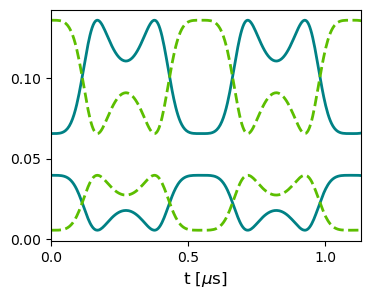

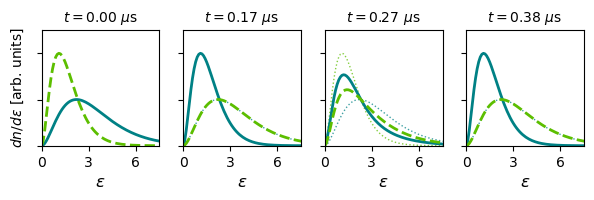

In [37]:
osc_plot(t_q, f_e_q, f_m_q, eps, "../coherent")

The figure below shows the fully QKE solution. There are slight differences, but they don't show up.

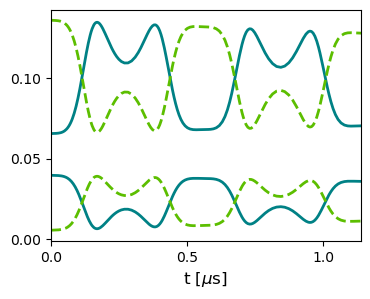

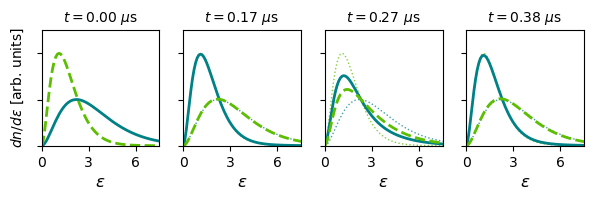

In [40]:
osc_plot(time, f_e, f_m, eps)

Here we demonstrate the semi-classical solution, just scattering. The first and last panel are the initial and final. The two intermediate panels are separated by equal changes in entropy.

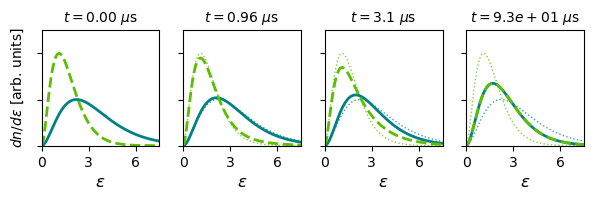

In [43]:
entropy_plot(t_class, sq_class, f_e_class, f_m_class, eps)

Same, but for the QKE solution. This is, perhaps, rough, because there's no clear indication of the oscillations in this picture.

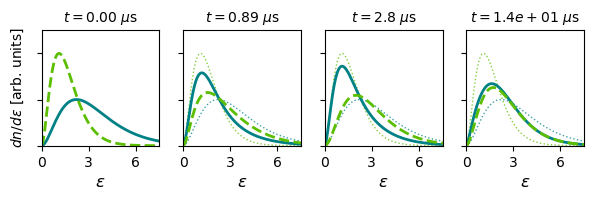

In [45]:
entropy_plot(time, sqke_q, f_e, f_m, eps)

Let's look at the effects of QKEs. The top plot is purely coherent, with $\epsilon = 1.5$. Middle plot has QKE solution for $\epsilon = 1.5$ (solid line) with the semi-classical scattering only solution (dashed line). Bottom plot is another QKE solution for $\epsilon = 4.5$. More precisely, the solid curves are all the occupation fractions for $\nu_e$. The dashed lines represent the scattering-only solution, with the envelope created by the $\nu_e$ and the $\nu_\mu$ scattering-only solutions.

We notice that the same character of the coherent solution persists in the QKE solution, until a sufficient amount of scattering has occurred. At the end, the character of the synchronous oscillations have changed. (Thought! need to process this more, but perhaps the change in the character occurs because information is lost due to scattering in the coherences...)

Text(0.5, 0, 't [$\\mu$s]')

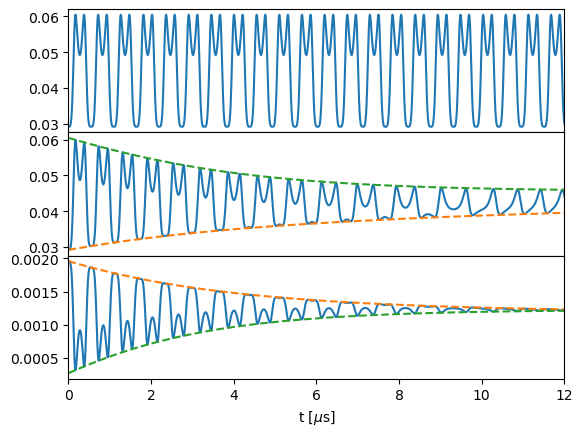

In [102]:
fig, ax = plt.subplots(nrows=3, ncols=1, sharex=True)
plt.subplots_adjust(hspace=0)

ax[1].plot(time*1e6, f_e[:,15])
ax[1].plot(t_class*1e6, f_e_class[:,15],ls='--')
ax[1].plot(t_class*1e6, f_m_class[:,15], ls='--')
ax[0].plot(t_q*1e6, f_e_q[:,15])
ax[2].plot(time*1e6, f_e[:,45])
ax[2].plot(t_class*1e6, f_e_class[:,45], ls='--')
ax[2].plot(t_class*1e6, f_m_class[:,45], ls='--')
ax[2].set_xlim(0,12)
ax[2].set_xlabel(r"t [$\mu$s]")

We take a closer look at the solutions, comparing the coherent solution (dotted) with the QKE solution (solid) for $\epsilon = 1.5$. We notice characteristics similar to comparing damped and undamped oscillators: the amplitude of oscillations are damped and the oscillation frequency decreases.

(0.0, 2.5)

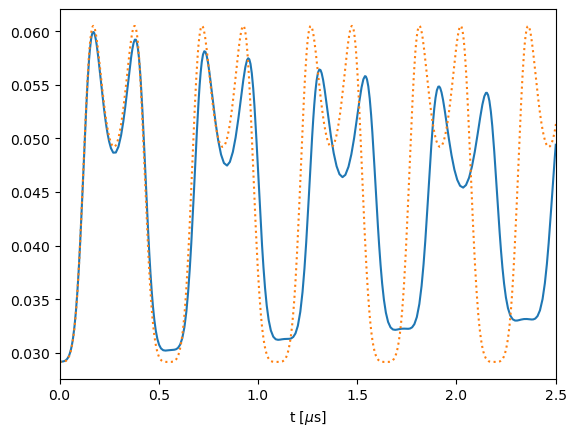

In [109]:
plt.plot(time*1e6, f_e[:,15])
plt.plot(t_q*1e6, f_e_q[:,15],ls=':')
plt.xlabel(r"t [$\mu$s]")
plt.xlim(0,2.5)